In [1]:
import matplotlib.pyplot as plt
import numpy as np

To model an axisymmetric body given by the equation $f(x) = \sqrt{y^2+z^2}$, we have derived the velocity potential 
$$ \Phi(\mathbf{r})=cx - \frac{1}{4\pi}\sum_{j=1}^N \frac{m_j}{\sqrt{(x-x_j)^2+y^2+z^2}}. $$
Here the source/sink strenghts $m_j$ can be solved for through the linear matrix equation $\mathbf{A}\mathbf{m}=\mathbf{b}$ where $\mathbf{m} = [m_1,\dots,m_N]^T$, $\mathbf{b} = 4\pi c[f'(x_1),\dots,f'(x_N)]^T$, and 
$$ A_{i,j} = \frac{-(x_i-x_j)f'(x_i)+f(x_i)}{((x_i-x_j)^2+f^2(x_i))^{3/2}} $$

# Part d)
Suppose the form of the axisymmetric body is
$$ f(x) = \epsilon \Big(\frac{L^2-x^2}{L^2}\Big), $$
and the points $x_j$ are distributed as 
$$ x_j = -L +2L\frac{j}{N+1}, \quad j\in\{1,\dots,N\}. $$

## Plot surface of axisymmetrix body

In [42]:
#Define Constants
L = 2 #L = 2
c = -0.1 #c = 1
eps = 1 #eps = 0.4
N = 10

#Define our function and derivative
def fx(x):
    #f = eps * (L**2 - x**2) / L**2
    f = eps * np.sqrt((L**2 - x**2) / L**2)*(1 + 0.5*x / L)
    return f

def deriv(x):
    #df = -2 * eps * x / L**2
    df = eps / L * (0.5 - x/L - x**2/L**2 )/ np.sqrt((L**2 - x**2) / L**2)
    return df

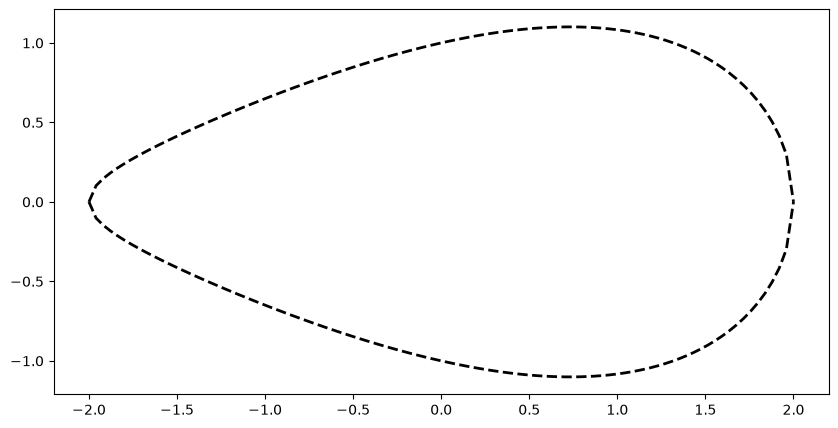

In [43]:
x_body = np.linspace(-L,L,100)

#Plot
fig = plt.figure(figsize=(10,5))
plt.plot(x_body,fx(x_body),'k--',linewidth=2)
plt.plot(x_body,-fx(x_body),'k--',linewidth=2)

## Plot locations of sources and sinks

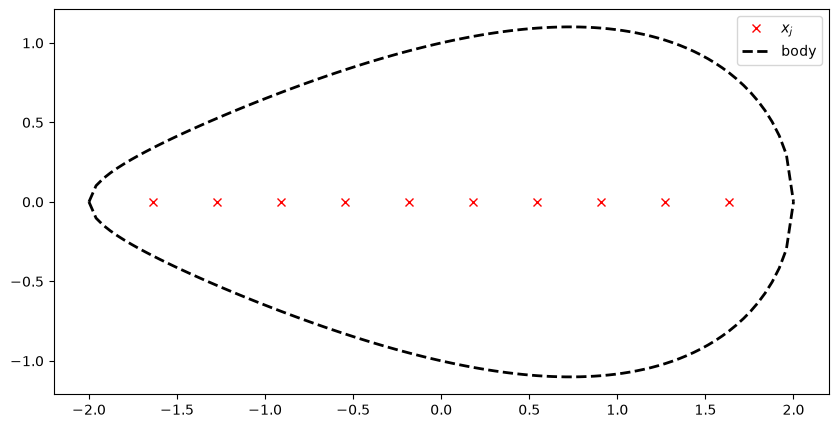

In [44]:
# initialise x as specified
x = np.linspace(-L*(1 - 2 / (N+1)) , -L * (1 - 2*N / (N+1)), N)

# plot
fig = plt.figure(figsize=(10,5))
plt.plot(x,0*x,'rx')
plt.plot(x_body,fx(x_body),'k--',linewidth=2)
plt.plot(x_body,-fx(x_body),'k--',linewidth=2)
plt.legend(['$x_j$','body'])

## Solve for source and sink strengths

In [45]:
#initialise b as specified
b = 4 * np.pi * c * deriv(x)

#initialise A (element-wise)
A = np.zeros((N, N))
for index, elem in np.ndenumerate(A):
    i = index[0]
    j = index[1]
    numerator = - (x[i]- x[j]) * deriv(x[i]) + fx(x[i])
    denominator = ((x[i]- x[j])**2 + fx(x[i])**2)**(3/2)
    A[index] = numerator / denominator

m = np.matmul(np.linalg.inv(A), b)

print("m:", m)

m: [-0.02962807 -0.06244194 -0.03582892 -0.14549679  0.00269356 -0.32302219
  0.21278992 -1.02300492  1.6041098  -0.20502979]


In [46]:
np.linalg.det(A)

np.float64(0.0003732396307162425)

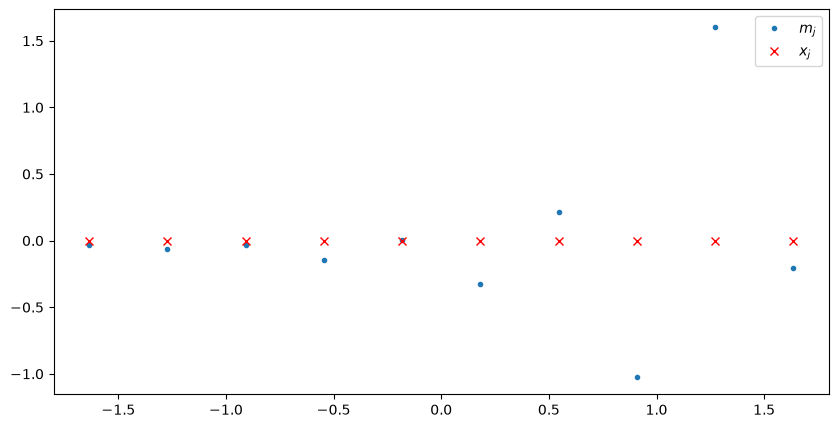

In [47]:
plt.figure(figsize=(10,5))
plt.plot(x,m,'.')
plt.plot(x,0*x,'rx')
plt.legend(['$m_j$','$x_j$'])

# Part e)
Plot the velocity potential and streamlines

In [48]:
x_array = x #Rename x

def potential(x,z):
    Phi = np.zeros(x.shape)
    
    #Loop over m and sum
    for index, m_val in np.ndenumerate(m):
        d = x_array[index] # - x
        m_long = np.full(x.shape, m_val)
        
        Phi += - m_val / (4*np.pi * ((x-d)**2 + z**2)**(1/2))
        
    #Add constant flow
    Phi += c * x
    
    return Phi

def velocity(x,z):
    u = np.zeros(x.shape)
    v = np.zeros(x.shape)
    
    #Loop over all sources and sum
    for index, m_val in np.ndenumerate(m):
        d = x_array[index]# - x
        m_long = np.full(x.shape, m_val)
        
        u +=  m_val * (x-d) / (4*np.pi * ((x-d)**2 + z**2)**(3/2))
        v +=  m_val * z / (4*np.pi * ((x-d)**2 + z**2)**(3/2))
        
    #Constant Flow    
    u += c*np.ones(x.shape)
    
    U = np.array([u, v])
    return U

#Define Coordinates and calculate values
x_space = np.linspace(-2.5, 2.5, 100)
z_space = np.linspace(-2.5, 2.5, 100)
X,Z = np.meshgrid(x_space, z_space)
U = velocity(X,Z)
u = U[0,:,:]
v = U[1,:,:]
pot =  potential(X,Z)


## Plot

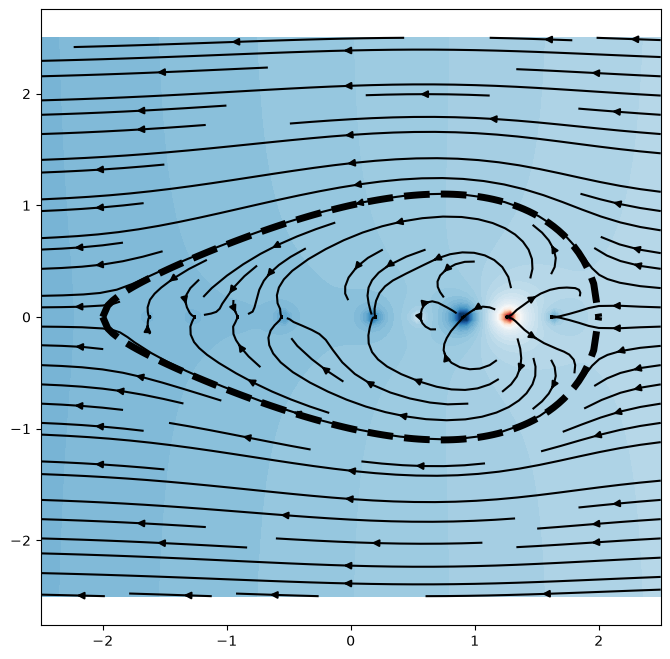

In [49]:
fig = plt.figure(figsize=(8,8))
p = plt.contourf(X, Z, pot, cmap='RdBu', levels = 100)#vmax= 100, vmin=-100)
plt.plot(x_body,fx(x_body),'k--',linewidth=5)
plt.plot(x_body,-fx(x_body),'k--',linewidth=5)
plt.streamplot(X,Z,u,v,color='k')
# plt.colorbar(p)
